In [2]:
import torch
import torchvision.models as models
import backbone.Test as test
import timm
import backbone.Custom as Custom
from torch.utils.data import Dataset, DataLoader
import backbone.VISUAL as viz
import backbone.GalaxyZoo as gz
import importlib
#import backbone.AstroMLmodified as AstroMLmod

import backbone.AstroMLmod3 as AstroMLmod


#saving purposes
import h5py
import numpy as np

def save_embeds(embeddings, labels, ids, file_path="model_data.h5"):
    with h5py.File(file_path, 'w') as f:
        # Compression='gzip' saves massive disk space for large arrays
        f.create_dataset("embeddings", data=embeddings, compression="gzip")
        f.create_dataset("labels", data=labels)
        f.create_dataset("ids", data=ids)
        
    print(f"Stored multiple arrays in {file_path}")



/users/koketso/.venv/deepclustering3/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
2026-05-13 22:08:32.250638: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:477] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1778702912.278542 2578660 cuda_dnn.cc:8310] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1778702912.287325 2578660 cuda_blas.cc:1418] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
2026-05-13 22:08:32.319733: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-



Failed to import TF-Keras. Please note that TF-Keras is not installed by default when you install TensorFlow Probability. This is so that JAX-only users do not have to install TensorFlow or TF-Keras. To use TensorFlow Probability with TensorFlow, please install the tf-keras or tf-keras-nightly package.
This can be be done through installing the tensorflow-probability[tf] extra.




<Figure size 640x480 with 0 Axes>

# Data

In [5]:
importlib.reload(gz)
train,val,class_  = gz.Galaxy_zoo_data_loaders(train_split = None, num_workers = 30)


knns = []
tpcfs = []
cas = []
ids = []

InvalidParameterError: The 'test_size' parameter of train_test_split must be a float in the range (0.0, 1.0), an int in the range [1, inf) or None. Got 0 instead.

## Model: Zoobot ConvNext Base

In [6]:
train = val

zoobot_encoder = timm.create_model('hf_hub:mwalmsley/zoobot-encoder-convnext_base', pretrained=True, 
                                   num_classes=0)


zoobot_rep, zoobot_label, zoobot_ids = Custom.get_representations(model  = zoobot_encoder,
                                       loader = train,
                                       encoder = True,
                                       labeled = False)

save_embeds(zoobot_rep, zoobot_label, zoobot_ids, file_path="zoobot_reps.h5")


zoobot_rep_c, zoobot_label_c, zoobot_ids_c = Custom.get_representations(model  = zoobot_encoder,
                                                                       loader = class_,
                                                                       encoder = True,
                                                                       labeled = True)


save_embeds(zoobot_rep_c, zoobot_label_c, zoobot_ids_c, file_path="zoobot_reps_c.h5")

Variance to keep :  0.994326424741254  number of components :  500
KNN:  (98.35, 0.08)
Length subset used:  1500
Clustering accuracy 0.9813333333333333
TPCF:  (4.96, 0.22)
ID:  (12.56961774978573, 0.18275290708588265)


## Model: Dino ConvNext base

In [ ]:
dinov3_convnext_base = torch.hub.load("../dinov3", 'dinov3_convnext_base',
                                      source='local',
                                      weights="dinov3_convnext_base_pretrain_lvd1689m-801f2ba9.pth")

print(dinov3_convnext_base)

dino_rep, dino_label, dino_ids = Custom.get_representations(model  = dinov3_convnext_base,
                           loader = train,
                           encoder = True,
                           labeled = False)


save_embeds(dino_rep, dino_label, dino_ids, file_path="dinov3_convnext_base_reps.h5")


dino_rep_c, dino_label_c, dino_ids_c = Custom.get_representations(model  = dinov3_convnext_base,
                           loader = class_,
                           encoder = True,
                           labeled = True)


save_embeds(dino_rep_c, dino_label_c, dino_ids_c, file_path="dinov3_convnext_base_reps_c.h5")

## Model: Dino Vision transformer huge

In [ ]:
dinov3_vith = torch.hub.load("../dinov3", 'dinov3_vith16plus',
                                      source='local',
                                      weights="dinov3_vith16plus_pretrain_lvd1689m-7c1da9a5.pth")

dinov3_vith_rep, dinov3_vith_label, dinov3_vith_ids = Custom.get_representations(model  = dinov3_vith,
                           loader = train,
                           encoder = True,
                           labeled = False)


save_embeds(dinov3_vith_rep, dinov3_vith_label, dinov3_vith_ids, file_path="dinov3_vith_reps.h5")


dinov3_vith_rep_c, dinov3_vith_label_c, dinov3_vith_ids_c = Custom.get_representations(model  =dinov3_vith,
                           loader = class_,
                           encoder = True,
                           labeled = True)

save_embeds(dinov3_vith_rep_c, dinov3_vith_label_c, dinov3_vith_ids_c, file_path="dinov3_vith_reps_c.h5")

## Model: ImageNet representations ConvNext base

In [ ]:
import torchvision as tv
weights = tv.models.ConvNeXt_Base_Weights.IMAGENET1K_V1

imnet_convnext_base = tv.models.convnext_base(weights = weights)
imnet_convnext_base.classifier[-1] = torch.nn.Identity()

imnet_rep, imnet_label, imnet_ids = Custom.get_representations(model  = imnet_convnext_base,
                           loader = val,
                           encoder = True,
                           labeled = False)

save_embeds(imnet_rep, imnet_label, imnet_ids, file_path="imnet_convnext_base_reps.h5")


imnet_rep_c, imnet_label_c, imnet_ids_c = Custom.get_representations(model  = imnet_convnext_base,
                           loader = class_,
                           encoder = True,
                           labeled = True)


save_embeds(imnet_rep_c, imnet_label_c, imnet_ids_c, file_path="imnet_convnext_base_reps_c.h5")

## Model: ResNet ImageNet representations ConvNext base

In [ ]:
import torchvision as tv
weights = tv.models.ResNet18_Weights.IMAGENET1K_V1 


imnet_resnet18 = tv.models.resnet18(weights = weights)
imnet_resnet18.eval()

imnet_resnet18.fc = torch.nn.Identity()

res_imnet_rep, res_imnet_label, res_imnet_ids = Custom.get_representations(model  = imnet_resnet18,
                           loader = val,
                           encoder = True,
                           labeled = False)



save_embeds(res_imnet_rep, res_imnet_label, res_imnet_ids, file_path="imnet_resnet18_reps.h5")


res_imnet_rep_c, res_imnet_label_c, res_imnet_ids_c = Custom.get_representations(model  = imnet_resnet18,
                           loader = class_,
                           encoder = True,
                           labeled = True)


save_embeds(res_imnet_rep_c, res_imnet_label_c, res_imnet_ids_c, file_path="imnet_resnet18_reps_c.h5")

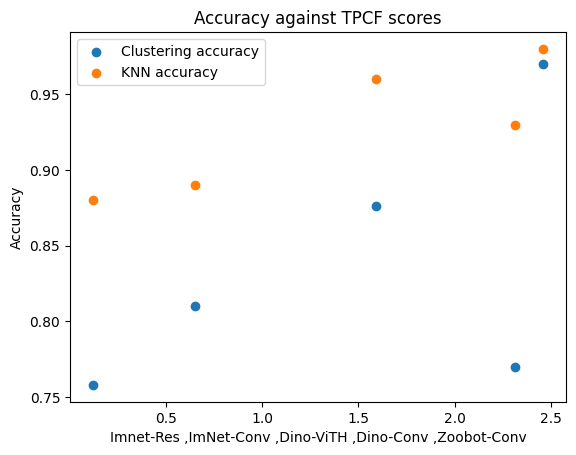

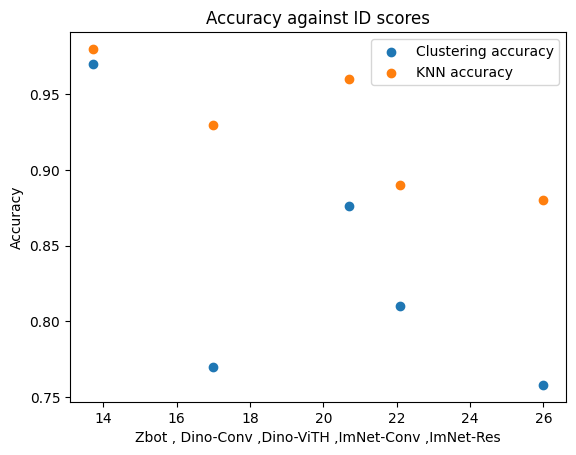

In [30]:
import matplotlib.pyplot as plt
#plt.scatter(tpcfs,cas)
"""

(93.83, 0.21)
Length subset used:  1500
Clustering accuracy 0.77
(1.01, 0.07)
(17.41159228404205, 0.24739873048202016)


KNN:  (88.39, 0.22)
Length subset used:  1500
Clustering accuracy 0.758
TPCF score:  (0.12, 0.05)
ID : (26.20292789003229, 0.2695953595103914)


Variance to keep :  0.9959315232422586  number of components :  500
(89.75, 0.22)
Length subset used:  1500
Clustering accuracy 0.8093333333333333
(0.65, 0.05)
(22.144800189889104, 0.23156879543123463)


(96.87, 0.1)
Length subset used:  1500
Clustering accuracy 0.876
(1.59, 0.13)
(20.686109686776764, 0.18925943991910896)


KNN:  (98.23, 0.15)
Length subset used:  1500
Clustering accuracy 0.974
TPCF:  (2.46, 0.04)
ID:  (13.717051102931771, 0.04575128383189965)
"""

plt.title("Accuracy against TPCF scores")

plt.scatter([2.46,2.31,0.12,0.65,1.59],[0.97,0.77,0.758,0.81,0.876], label = "Clustering accuracy")

plt.scatter([2.46,2.31,0.12,0.65,1.59],[0.98,0.93,0.88,0.89,0.96], label = "KNN accuracy")
plt.ylabel("Accuracy")



plt.xlabel("Imnet-Res ,ImNet-Conv ,Dino-ViTH ,Dino-Conv ,Zoobot-Conv")
plt.legend()
#plt.xticks([2.46,2.31,0.12,0.65,1.59],["ZBot","Dino-ConvN","Imnet-Res","ImNet-ConvN","Dino-ViTH"])




plt.show()

plt.title("Accuracy against ID scores")

plt.scatter([13.71,17,26,22.1,20.7],[0.97,0.77,0.758,0.81,0.876], label = "Clustering accuracy")

plt.scatter([13.71,17,26,22.1,20.7],[0.98,0.93,0.88,0.89,0.96], label = "KNN accuracy")

plt.xlabel("Foundation model")
plt.ylabel("Accuracy")
plt.legend()

#plt.xticks([13.71,17,26,22.1,20.7],["ZBot","Dino-ConvN","Imnet-Res","ImNet-ConvN","Dino-ViTH"])
plt.xlabel("Zbot , Dino-Conv ,Dino-ViTH ,ImNet-Conv ,ImNet-Res")



plt.show()



## Clustering accuracy